In [ ]:
#Basic Dataset Statistics
#Load processed data
import pandas as pd


df = pd.read_csv("../data/processed/processed_dataset.csv", encoding="utf-8")
df.head()

,Comment,Label,Comment_clean,Label_id
0,movie vara level la Erika poguthu,NON_HATE,movie vara level la erika poguthu,0
1,Padam nalla comedy padama irukum polaye..,NON_HATE,padam nalla comedy padama irukum polaye..,0
2,karthick subburaj anne .. intha padam vetri ad...,NON_HATE,karthick subburaj anne .. intha padam vetri ad...,0
3,கவுண்டர் தேவர்.சார்பாக வெற்றி பெற வாழ்த்துக்கள் 🦁,NON_HATE,கவுண்டர் தேவர்.சார்பாக வெற்றி பெற வாழ்த்துக்கள் 🦁,0
4,ippo intha trailer ah parkuravana oru like pod...,NON_HATE,ippo intha trailer ah parkuravana oru like pod...,0


In [14]:
#Number of samples
print("Total samples:", len(df))


Total samples: 47539


In [15]:
#Label distribution (HATE vs NON_HATE)
df["Label"].value_counts()


Label
NON_HATE    37817
HATE         9722
Name: count, dtype: int64

In [16]:
df["Label"].value_counts(normalize=True) * 100

Label
NON_HATE    79.549423
HATE        20.450577
Name: proportion, dtype: float64

In [17]:
#Check missing values
df.isnull().sum()

Comment          1
Label            0
Comment_clean    1
Label_id         0
dtype: int64

In [18]:
#remove missing values
df = df.dropna()

In [19]:
#Simple Text Length Analysis
df["text_length"] = df["Comment_clean"].str.split().str.len()
df["text_length"].describe()


count    47538.000000
mean         9.748917
std          7.591171
min          1.000000
25%          6.000000
50%          8.000000
75%         11.000000
max        275.000000
Name: text_length, dtype: float64

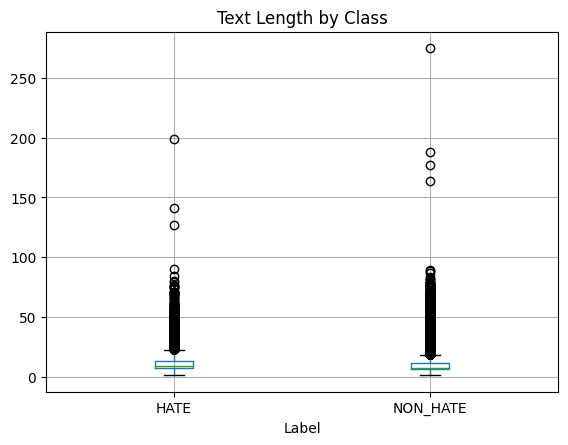

In [21]:
import matplotlib.pyplot as plt

df.boxplot(column="text_length", by="Label")
plt.suptitle("")
plt.title("Text Length by Class")
plt.show()


In [22]:
#Train / Validation / Test Split
from sklearn.model_selection import train_test_split
X = df["Comment_clean"]
y = df["Label_id"]

# First split: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: val + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(len(X_train), len(X_val), len(X_test))

33276 7131 7131


In [23]:
#Save splits
train_df = pd.DataFrame({"text": X_train, "label": y_train})
val_df   = pd.DataFrame({"text": X_val, "label": y_val})
test_df  = pd.DataFrame({"text": X_test, "label": y_test})

train_df.to_csv("../data/processed/train.csv", index=False, encoding="utf-8")
val_df.to_csv("../data/processed/val.csv", index=False, encoding="utf-8")
test_df.to_csv("../data/processed/test.csv", index=False, encoding="utf-8")